INTRODUCTION

Le marché de l'immobilier est l'un des secteurs économiques les plus importants au monde.
Chaque année, ce sont des centaines de milliards de dollars de transactions immobilières qui sont effectuées Les investisseurs les plus avertis. utilisent les outils de Data Science et de Machine Learning pour analvser les données et en tirer des informations importantes. Ces informations leur permettent de prendre de meilleures décisions par rapport à leurs investissements.

Dans ce projet, nous traiterons d'un cas d'application de l'apprentissage automatique supervisé à l'industrie immobilière. Il s'agira de construire un modèle de régression linéaire capable de prédire le prix d'une maison en fonction de certains de ses attributs.

In [136]:
# Librairies                                                                               # Le 04/05/2025
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from fractions import Fraction

from scipy import stats

DONNEES

L'ensemble de données que nous utiliserons contient des informations sur un ensemble de maison dans la région de Boston.

### Importation des données

In [137]:
#"E:/DSTI/Cours/Machine_Learning_2025/requetes_python/ML_Projet/marketing.csv"

In [138]:
df = pd.read_csv("E:/DSTI/Cours/Machine_Learning_2025/requetes_python/ML_Projet/Boston.csv")

In [139]:
df 

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


### Analyse exploratoire des données(EDA)

#### 1_Collecte des données

In [140]:
# Voir les types de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1    ZN      506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [141]:
df.columns

Index(['CRIM', ' ZN ', 'INDUS ', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')

In [142]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [143]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,7.88,11.9


In [144]:
df.shape

(506, 13)

La dataframe contient 506 lignes (chaque ligne représente une maison) et 13 variables. La variable MEDV est notre variable d'intérêt. Elle indique la valeur médiane des logements occupés par leur propriétaire en 1000 $.

In [145]:
#(Median value of owner-occupied homes (in $1000S =valeur médiane des maisons occupées par leur propriétaire 
#(en milliers de dollars))

In [146]:
# Traitemnt des données manquantes
df.isna().sum()

CRIM       0
 ZN        0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

Apparemment, il n'y a pas de valeurs manquantes dans la dataframe.C'est une bonne nouvelle!

In [147]:
# voir l’occurrence (fréquence) de chaque valeur dans une colonne
df["MEDV"].value_counts()

MEDV
50.0    16
25.0     8
23.1     7
22.0     7
21.7     7
        ..
12.6     1
16.4     1
17.7     1
12.0     1
8.1      1
Name: count, Length: 229, dtype: int64

In [148]:
# Renvoyer toutes les valeurs uniques présentes dans la colonne "MEDV" du DataFrame df.
df["MEDV"].unique()

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 13.6, 19.6, 15.2, 14.5,
       15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 13.2, 13.1, 13.5, 20. ,
       24.7, 30.8, 34.9, 26.6, 25.3, 21.2, 19.3, 14.4, 19.4, 19.7, 20.5,
       25. , 23.4, 35.4, 31.6, 23.3, 18.7, 16. , 22.2, 33. , 23.5, 22. ,
       17.4, 20.9, 24.2, 22.8, 24.1, 21.4, 20.8, 20.3, 28. , 23.9, 24.8,
       22.5, 23.6, 22.6, 20.6, 28.4, 38.7, 43.8, 33.2, 27.5, 26.5, 18.6,
       20.1, 19.5, 19.8, 18.8, 18.5, 18.3, 19.2, 17.3, 15.7, 16.2, 18. ,
       14.3, 23. , 18.1, 17.1, 13.3, 17.8, 14. , 13.4, 11.8, 13.8, 14.6,
       15.4, 21.5, 15.3, 17. , 41.3, 24.3, 27. , 50. , 22.7, 23.8, 22.3,
       19.1, 29.4, 23.2, 24.6, 29.9, 37.2, 39.8, 37.9, 32.5, 26.4, 29.6,
       32. , 29.8, 37. , 30.5, 36.4, 31.1, 29.1, 33.3, 30.3, 34.6, 32.9,
       42.3, 48.5, 24.4, 22.4, 28.1, 23.7, 26.7, 30.1, 44.8, 37.6, 46.7,
       31.5, 31.7, 41.7, 48.3, 29. , 25.1, 17.6, 24

In [149]:
# Compter combien de valeurs différentes il y a dans la colonne "MEDV".
# Il y a 229 valeurs différent dans cette colonnes

df["MEDV"].nunique()

229

Nous pouvons aussi vérifier s'il y a des lignes completes dupliquées et les supprimer.

In [150]:
df.duplicated()  # Il n'ya pas de lignes entières dupliquées

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505    False
Length: 506, dtype: bool

In [151]:
# Nombre de lignes entièrs dupliquées
# Le résultat est 0,  Aucune ligne dupliquée

df.duplicated().sum()

np.int64(0)

Il n'y a pas de lignes entièrs dupliquées.

##### Resumé statistiques

In [152]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


Le tableau df.describe() montre un résumé statistique des 506 quartiers analysés dans le dataset. On observe une grande variété socio-économique et urbaine : certains quartiers ont un taux de criminalité très bas, d'autres extrêmement élevé (jusqu’à 89). Le nombre moyen de pièces par maison est raisonnable (~6), mais les prix des logements (MEDV) atteignent un plafond de 50 000 $, ce qui peut indiquer une censure des prix. La variable LSTAT montre une forte inégalité sociale, avec des quartiers où jusqu’à 38 % de la population est défavorisée. Globalement, le dataset présente une forte hétérogénéité et contient des valeurs extrêmes importantes à analyser plus en détail

Une Analyse juste sur la première colonne (CRIM), La moyenne est beaucoup plus petite que l'écart-type, ce qui signifie que les données sont très asymétriques avec des valeurs extrêmes (outliers).

In [153]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


#### corrélation entere les variables

In [154]:
# Importation de la bibliothèque seaborn
import seaborn as sns

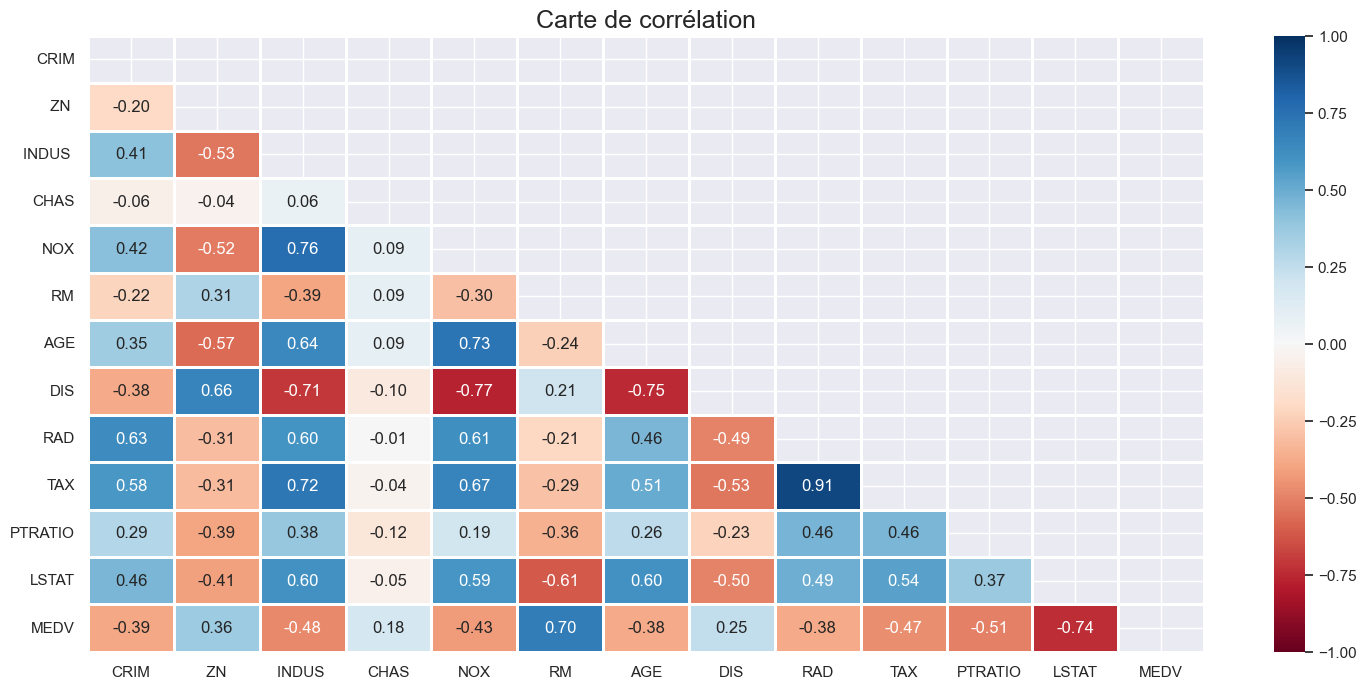

In [155]:
# Carte de corrélation

sns.set(rc = {"figure.figsize" : (18, 8)})
mask = np.triu(np.ones_like(df.corr(), dtype=bool))

sns.heatmap(df.corr(),
           mask=mask,
           center=0,
           cmap="RdBu",
           linewidths=1,
           annot=True,
            fmt=".2f",
            vmax=1,
            vmin=-1)

plt.xlabel("")
plt.ylabel("")
plt.title("Carte de corrélation", fontsize=18)
plt.show()

Cette carte nous indique la force des relations linéaires entre les variables indépendantes d'une part et entre chacune de ces variables avec la variable cible. Plus le carré est rouge, plus la corrélation entre les deux variables est forte et négative. Plus le carré est bleu, plus la corrélation entre les deux variables est forte et positive. Par exemple, il y a une forte corrélation positive entre la variable cible MEDV (Median value of owner-occupied homes (in $1000S =aleur médiane des maisons occupées par leur propriétaire (en milliers de dollars)) et la variable RM5(Average number of rooms per dwelling = Nombre moyen de pièces par logement) qui indique le nombre moyen de pièces par logement. Autrement dit plus la maison a de pièces, plus son prix est élevé (ce qui est tout à fait logique).




#### Le 05/05/25

### DISTRIBUTION DES VARIABLES

Nous pouvons visualiser d'un seul coup la distribution de chaque variable avec la fonction (pairplot()). Comme vous pouvez voir ci-dessous.

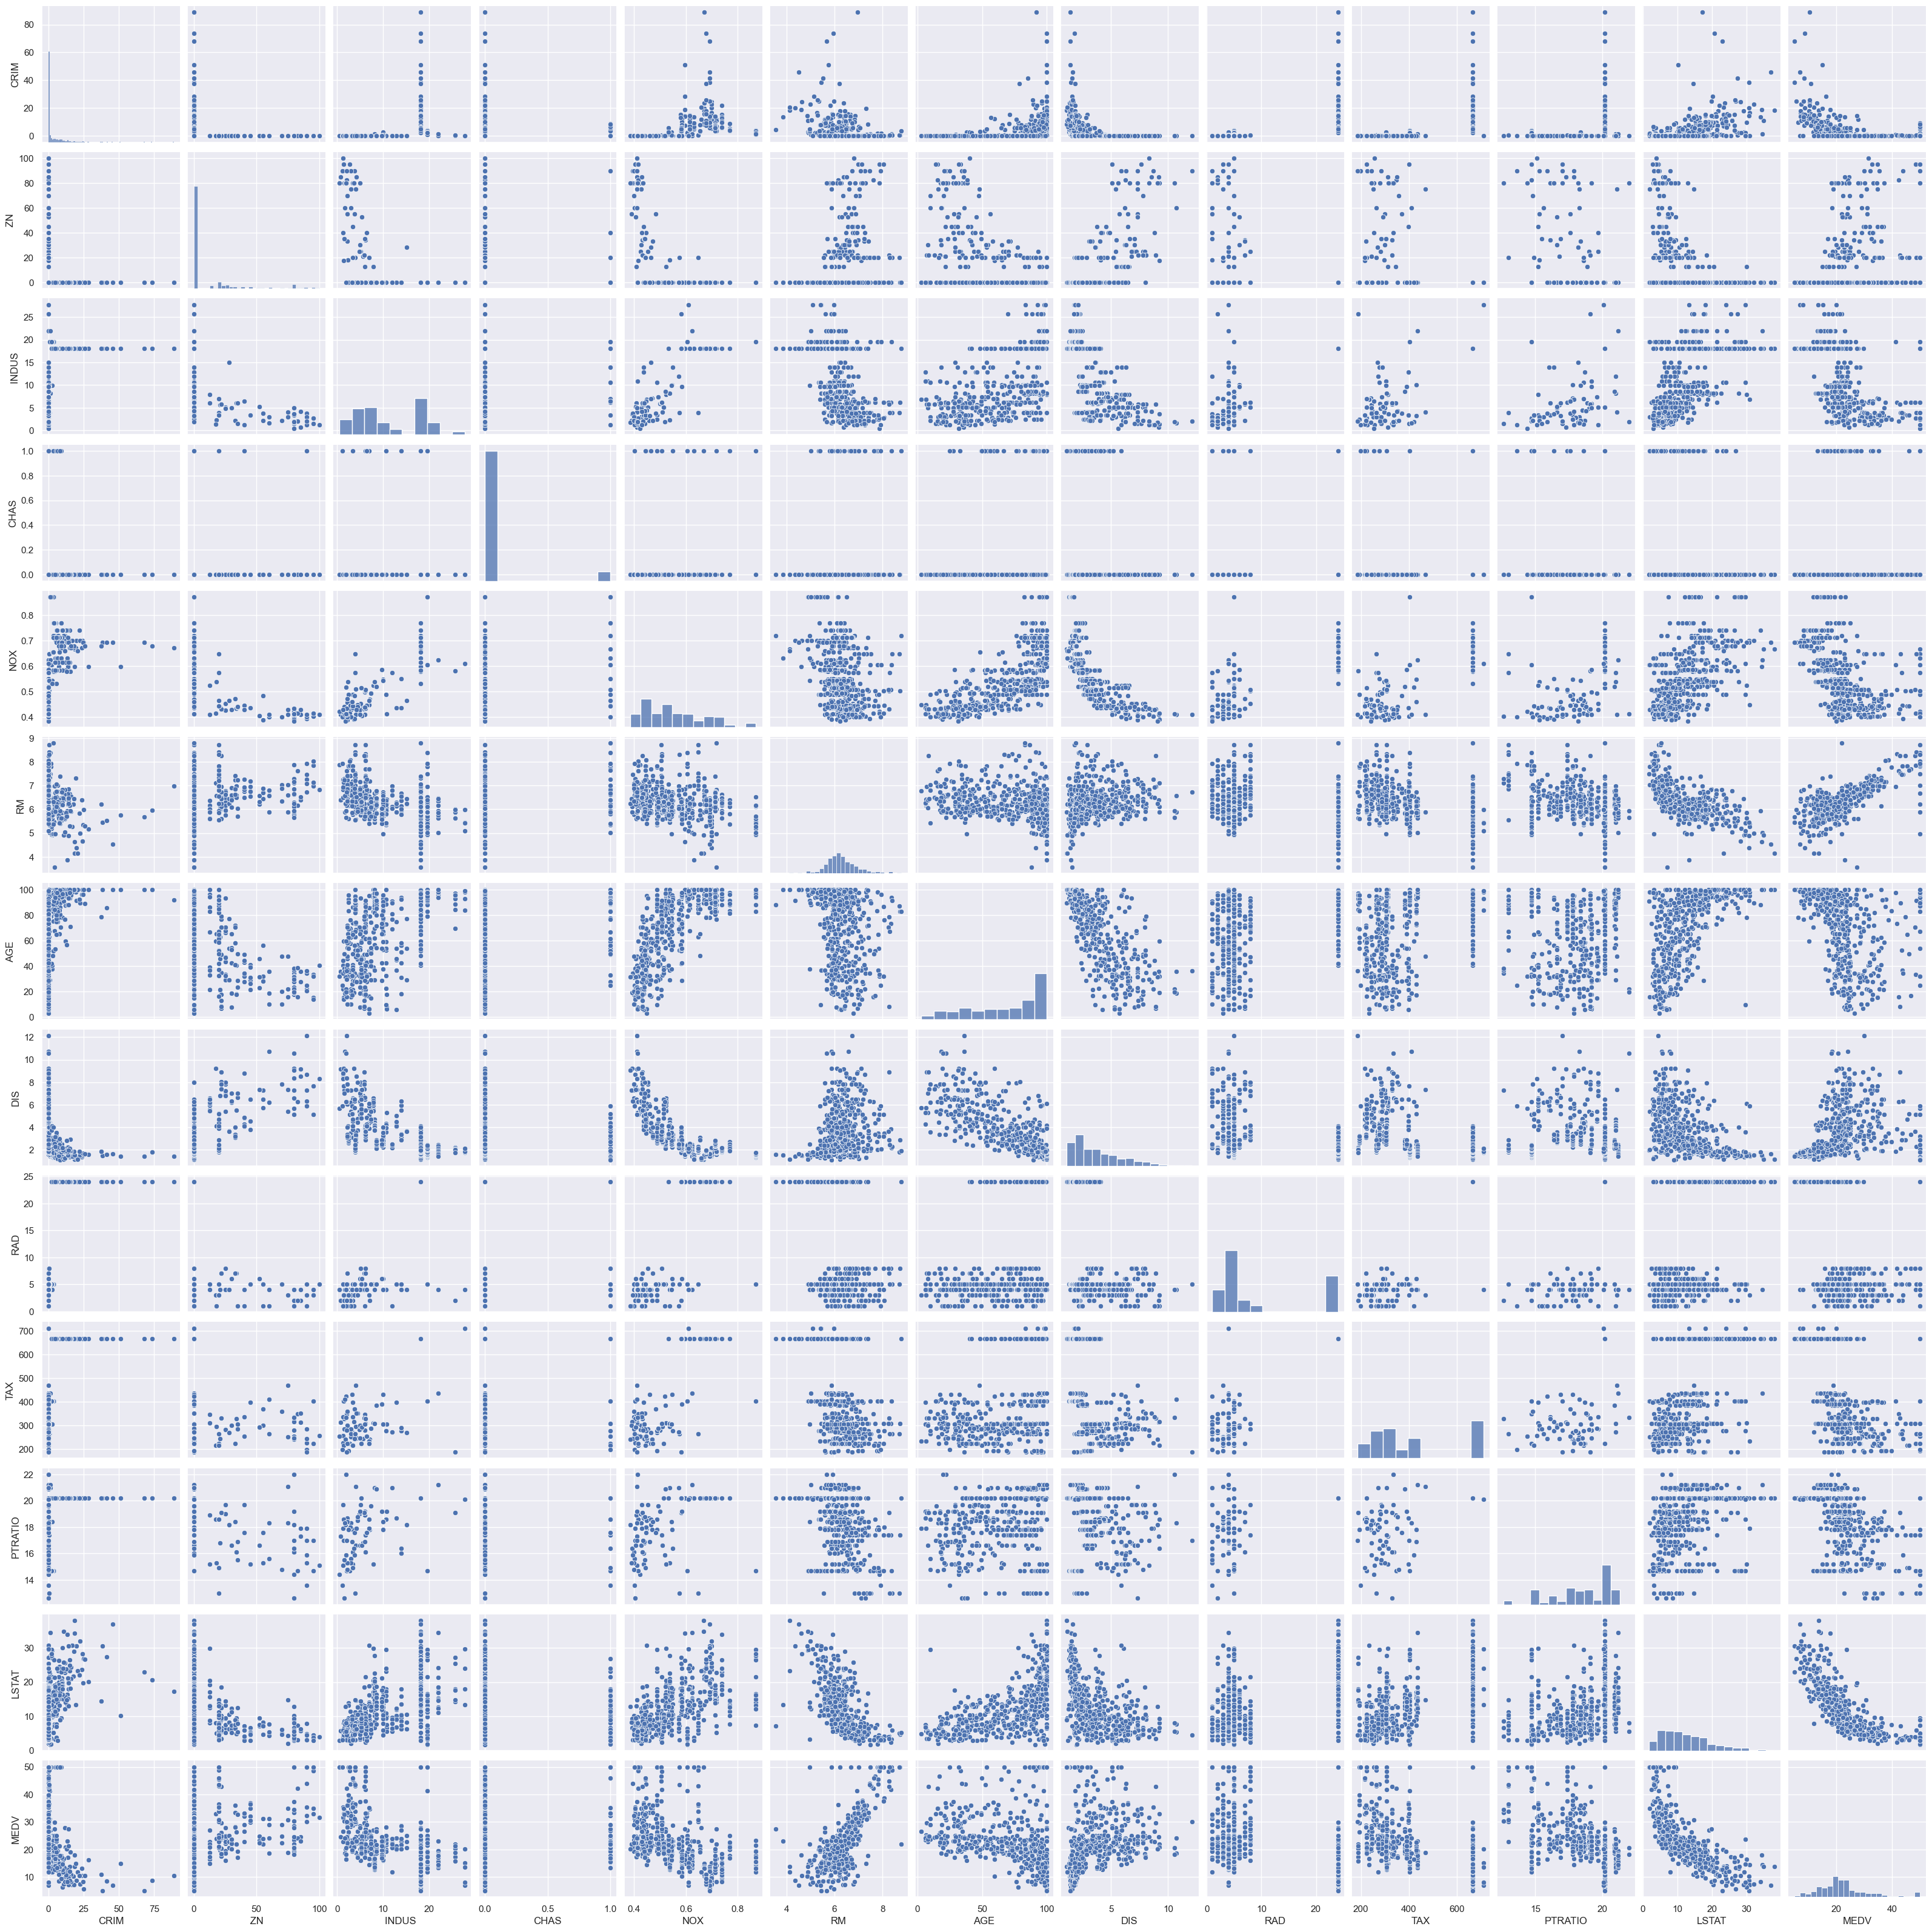

In [156]:
sns.pairplot(df)
plt.show()

La fonction pairplot " trace des relations par paires dans un jeu de données. Par défaut, cette fonction crée une grille d'axes de telle sorte que chaque variable numérique dans les données sera partagée dans l'axe des y sur une seule ligne et dans l'axe des x sur une seule colonne. 
Les axes diagonaux sont traités différemment, dessinant un tracé pour montrer la distribution univariée des données pour la variable dans cette colonne.

Nous pouvons aussi tracer séparément chaque histogramme. Traçons par exemple la distribution de la variable d'intérêt (MEDV), voir ci-dessous.

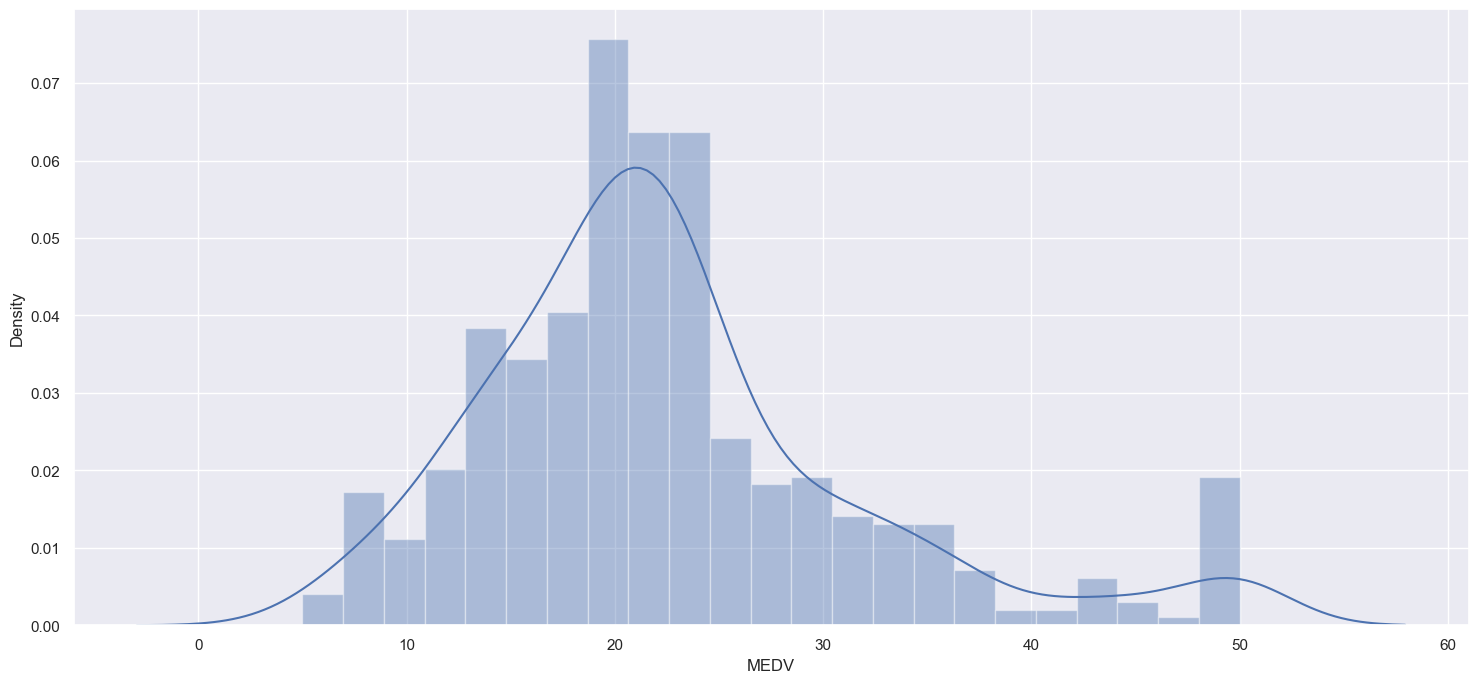

In [157]:
# Histogramme de la variable cible

sns.distplot(df["MEDV"])
plt.show()

Selon ce graphique, la distribution de la variable cible suit quasiment une loi normale.

 Pourquoi s'intéresse-t-on si tant aux distributions des variables ?

La plupart des algorithmes de Machine Learning sont conçus selon l'hypothèse que les variables d'entrées suivent une loi normale. Si ce n'est pas le cas, cela peut affecter énormément la qualité du modèle et conduire à de mauvaises prédictions. Il existe plusieurs techniques de transformations de variables pour normaliser les variables (la transformation logarithmique par exemple). Afin d'être plus confiant sur la distribution de chaque variable par rapport à la loi normale, nous allons calculer les degrés d'asymétrie. Une distribution normale a un degré d'asymétrie égal à 0. Donc une variable suit la loi normale lorsque son degré d'asymétrie est proche de 0.

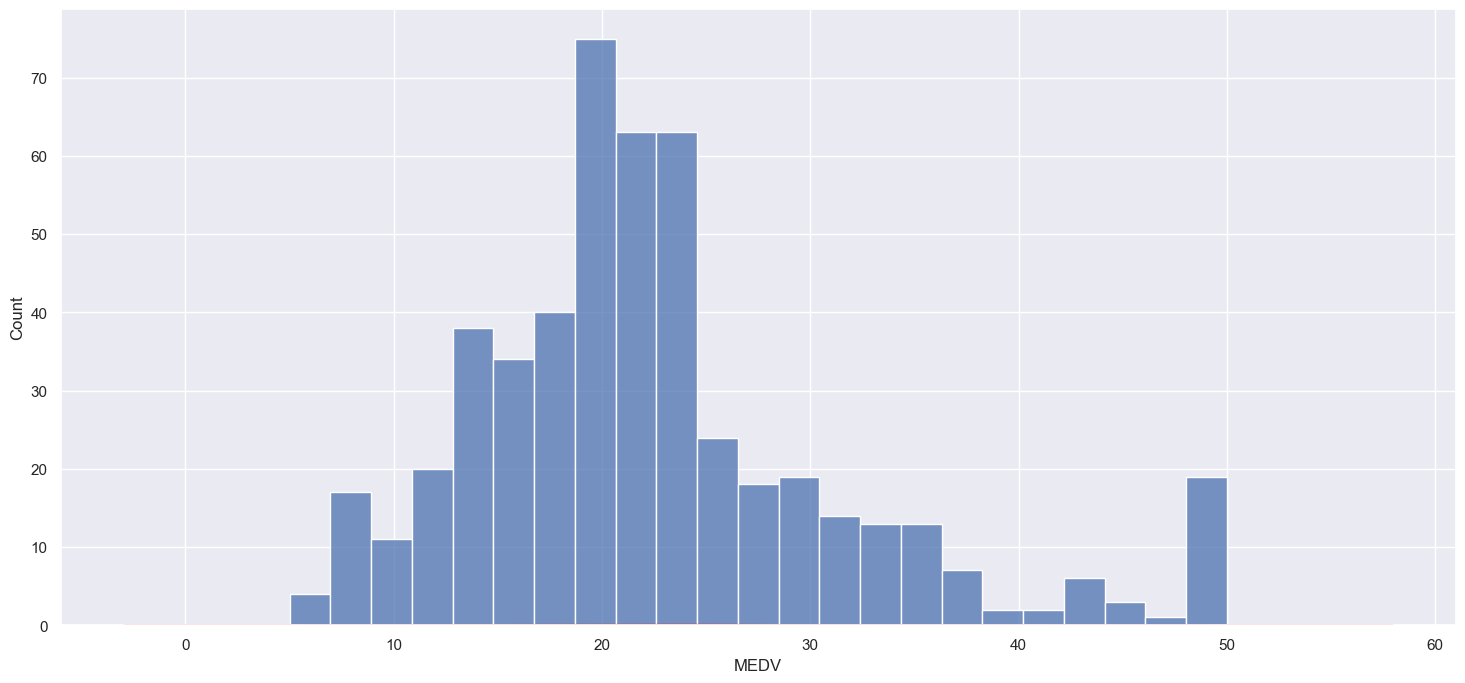

In [158]:
sns.histplot(df["MEDV"], kde=False)
sns.kdeplot(df["MEDV"], color="red")
plt.show()

<Axes: xlabel='MEDV', ylabel='Density'>

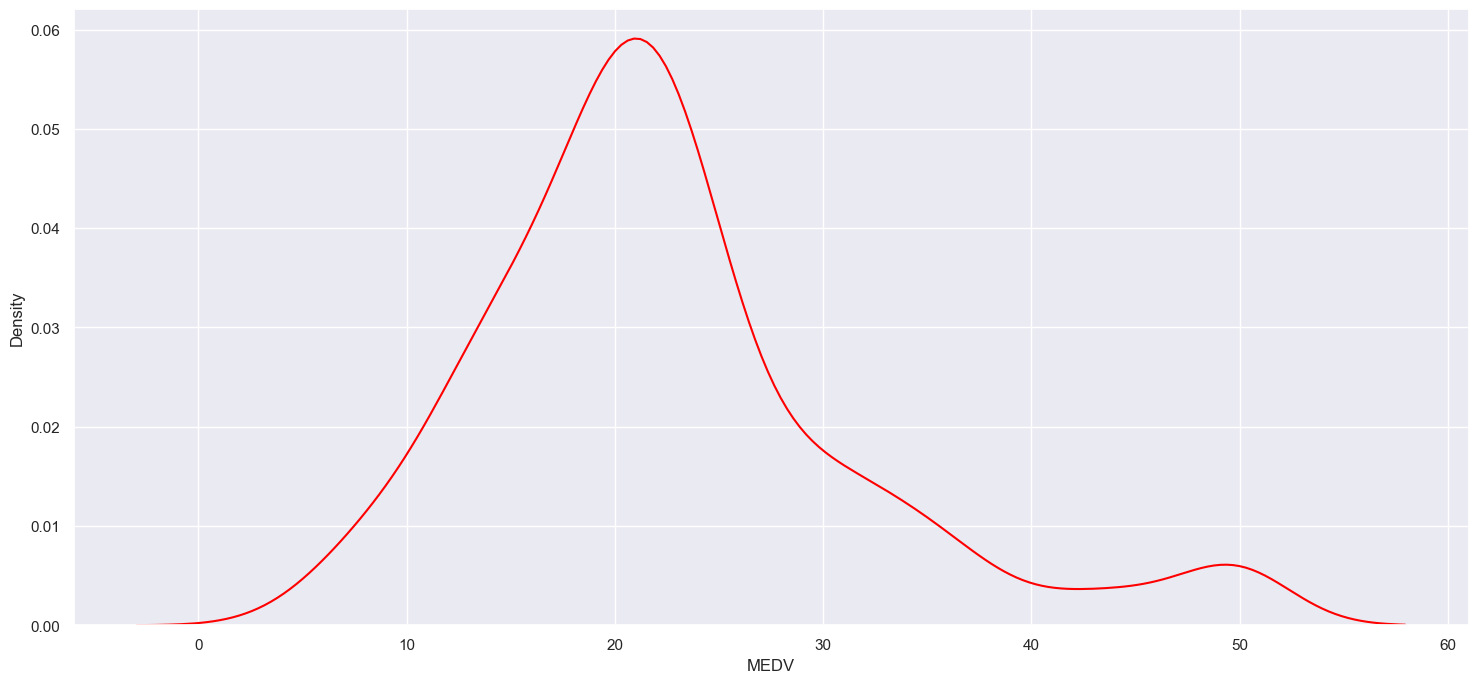

In [159]:
sns.kdeplot(df["MEDV"], color="red")

In [160]:
# Calcul de dégrés d'assymétrie
# Une variable suit la loi normale lorsque son degré d'asymétrie est proche de 0.

df.skew().sort_values()

PTRATIO   -0.802325
AGE       -0.598963
INDUS      0.295022
RM         0.403612
TAX        0.669956
NOX        0.729308
LSTAT      0.906460
RAD        1.004815
DIS        1.011781
MEDV       1.108098
 ZN        2.225666
CHAS       3.405904
CRIM       5.223149
dtype: float64

In [161]:
# Voyons la varible intérêt

df["MEDV"].skew()

np.float64(1.1080984082549072)

D'après ces résultats, les variables ayant les plus forts degrés d'asymétrie sont : ZN (proportion de terrains résidentiels zonés pour les lots de plus de 25 000 sq.ft.),

CHAS (Variable fictive de Charles River égale à 1 si la zone délimite la rivière et 0 sinon) et CRIM (taux de criminalité par habitant par ville).

In [162]:
#Transformation logarithmique des variables 'CRIM', 'RAD', 'DIS', 'MEDV', 'CHAS' et 'ZN'

In [163]:
#Transformation logarithmique des variables 'CRIM', 'RAD', 'DIS', 'MEDV', 'CHAS' et 'ZN'

df['CRIM'] = np.log(df['CRIM'])
df['RAD'] = np.log(df['RAD'])
df['DIS'] = np.log(df['DIS'])
df['MEDV'] = np.log(df['MEDV'])
df['CHAS'] = np.log(df['CHAS'] + 1 )
#df['ZN'] = np.log(df['ZN'] + 1 )

In [164]:
df.skew().sort_values()

PTRATIO   -0.802325
AGE       -0.598963
MEDV      -0.330321
DIS        0.152730
RAD        0.286617
INDUS      0.295022
RM         0.403612
CRIM       0.405934
TAX        0.669956
NOX        0.729308
LSTAT      0.906460
 ZN        2.225666
CHAS       3.405904
dtype: float64

#### Le 06/05/2025

Supprimons la variable "CHAS" à cause de son coefficient d'asymétrie trop élevé par rapport à celui des autres variables :

In [165]:
df.drop("CHAS",
       axis=1,
       inplace = True)

Traçons une nouvelle carte de corrélation afin de voir si les relations linéaires ont été rnforcées ou pas après la transformation logarithmique de certaines variables :

<Axes: >

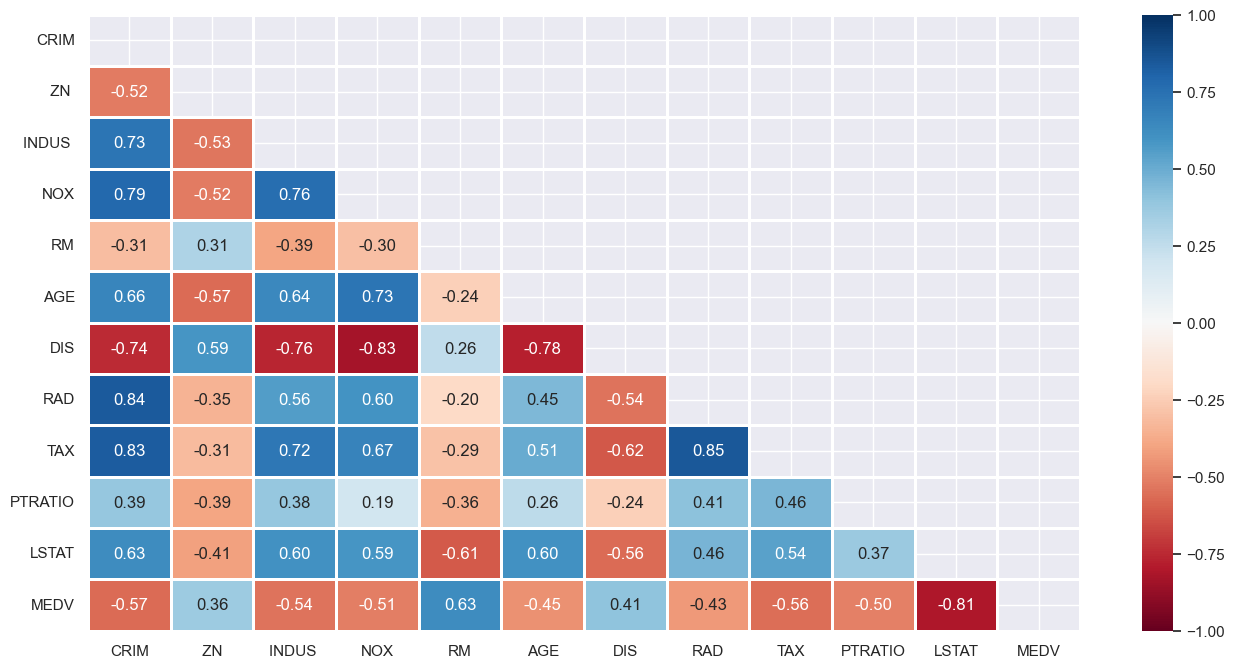

In [166]:
sns.set(rc = {"figure.figsize" : (16, 8)})
mask = np.triu(np.ones_like(df.corr(),
                           dtype=bool))
sns.heatmap(df.corr(),
           mask=mask,
           center=0,
           cmap="RdBu",
           linewidths=1,
           annot=True,
           fmt=".2f",
           vmax=1,
           vmin= -1)

In [167]:
sns.set(rc={"figure.figsize":(15, 7)})

En comparant cette nouvelle carte des corrélations à l'ancienne, nous remarquons effectivement un renforcement de la relation linéaire entre plusieurs variables. Par exemple, la relation linéaire entre la variable 'CRIM' et la variable cible s'est nettement améliorée (-0,39 à -0,57).

### Modélisation

Avant de passer à la construction du modèle, divisons d'abord la dataframe en données qui serviront à entraîner le modèle (train data) et en données d'évaluation de la performance du modèle (test data). Ainsi, nous pourrons mesurer la capacité de notre modèle à s'ajuster à de nouvelles données. Cette division se fait avec la fonction train test split.12

In [168]:
# DataFrame de variables indépendantes ou features; 
x=df.drop(["MEDV"],
         axis=1) 

In [169]:
x

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,-5.064036,18.0,2.31,0.538,6.575,65.2,1.408545,0.000000,296,15.3,4.98
1,-3.600502,0.0,7.07,0.469,6.421,78.9,1.602836,0.693147,242,17.8,9.14
2,-3.601235,0.0,7.07,0.469,7.185,61.1,1.602836,0.693147,242,17.8,4.03
3,-3.430523,0.0,2.18,0.458,6.998,45.8,1.802073,1.098612,222,18.7,2.94
4,-2.672924,0.0,2.18,0.458,7.147,54.2,1.802073,1.098612,222,18.7,5.33
...,...,...,...,...,...,...,...,...,...,...,...
501,-2.770511,0.0,11.93,0.573,6.593,69.1,0.907694,0.000000,273,21.0,9.67
502,-3.095111,0.0,11.93,0.573,6.120,76.7,0.827460,0.000000,273,21.0,9.08
503,-2.800824,0.0,11.93,0.573,6.976,91.0,0.773574,0.000000,273,21.0,5.64
504,-2.211009,0.0,11.93,0.573,6.794,89.3,0.870833,0.000000,273,21.0,6.48


Pour obtenir la DataFrame des variables indepentes, nous avons juste supprimé la variable cible de df, Comme vous avez vu ci-dessus.

In [170]:
# Variable cible ou target
y= df["MEDV"]

In [171]:
y

0      3.178054
1      3.072693
2      3.546740
3      3.508556
4      3.589059
         ...   
501    3.109061
502    3.025291
503    3.173878
504    3.091042
505    2.476538
Name: MEDV, Length: 506, dtype: float64

In [172]:
# Train/Test Data
seed =111           # Jusqu'au 111e test nous aurons le même modele
test_size = 0.2     # 20% de données seront utilisées pour le test(Pour évaluation de la performance du model)
                    # 80" de données seront utilisées pour l'entrainement

seed Définition : seed est une valeur utilisée pour initialiser le générateur de nombres aléatoires. Utilité : Fixer une valeur pour seed permet de garantir que la randomisation soit reproductible. Cela signifie que chaque fois que vous exécutez le code avec la même valeur de seed, vous obtiendrez la même division des données. Exemple : Si seed = 111, cela signifie que le générateur de nombres aléatoires est initialisé avec la valeur 111.

test_size Définition : test_size est un paramètre qui définit la proportion du dataset à inclure dans l'ensemble de test. Utilité : Ce paramètre contrôle combien de données seront utilisées pour évaluer le modèle après son entraînement. Exemple : Si test_size = 0.2, cela signifie que 20% des données totales seront utilisées pour le test et 80% seront utilisées pour l'entraînement

In [173]:
#!pip install scikit-learn

#### Le 08/05/25

In [174]:
from sklearn.model_selection import train_test_split

In [175]:
x_train, x_test, y_train, y_test = train_test_split(x, 
                                                    y,
                                                    test_size=test_size, 
                                                    random_state = seed)

In [176]:
# Affichage de dimensions
print("x_train :", x_train.shape)
print("y_train :", y_train.shape)

print("x_test :", x_test.shape)
print("y_test :", y_test.shape)


x_train : (404, 11)
y_train : (404,)
x_test : (102, 11)
y_test : (102,)


Lorsqu'on divise les données, la grande partie est utilisée comme données d'entraînement et le reste comme données d'évaluation. Ici, nous avons choisi une taille de données de test égale à 20% du total des observations. Le paramètre random state permet d'obtenir une division reproductible à chaque fois que nous exécutons ce code. Passons à présent à la construction du modèle.

In [177]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [178]:
from sklearn.linear_model import LinearRegression

In [179]:
# Création du modèle 
model = LinearRegression()

In [180]:
# Entrainement de l'algorithme
model.fit(x_train, y_train)

LinearRegression()

Nous avons d'abord défini un modèle de régression linéaire (variable model) puis nous l'avons ajusté aux données d'entraînement. La méthode d'ajustement fit() de l'objet modèle a été appelée pour ajuster le modèle de régression linéaire aux données. L'ajustement consiste à estimer les coéfficient de regression (paramètres) en utilisant la méthode de moindre carrés ordinaires.

Une fois que le modèle est ajusté aux données, nous pouvons calculer certains paramètres le coefficients de determination (R²) , l'erreur quadratique moyenne (MSE) et afficher les coéfficients ainsi que l'ordonnée à l'origine.

In [181]:
# Coéfficient de determination (R²)
model.score(x_train, y_train)

0.7602892729412419

Le Coéfficient de determination est égal à 0.76. 

76 % de la variance des données cibles (y_train) est expliquée par le modèle à partir des variables indépendantes (x_train).

In [182]:
# Le coéfficient du mondèle
model.coef_

array([-2.07176267e-02,  5.89217728e-04,  4.17811170e-03, -7.44369334e-01,
        9.39810101e-02, -2.01879042e-04, -2.20314458e-01,  1.09078074e-01,
       -7.08230358e-04, -3.39620848e-02, -3.30393291e-02])

Connaissant ces coefficients, nous pouvons écrire une équation de la variable cible égale à une combinaison linéaire des prédicteurs. 

Avant de calculer l'erreur quadratique moyenne, nous devons générer les prédictions c'est-à-dire les valeurs de la variable MEDV calculées par notre modèle.

In [183]:
# Préduction sur le train data
y_pred =model.predict(x_train)

In [184]:
y_pred

array([3.6988904 , 3.16858538, 3.23417254, 2.79547096, 2.76267396,
       3.69484417, 3.4130566 , 2.48970999, 2.80005074, 2.36583751,
       3.19055807, 3.12484877, 3.38089897, 2.77857328, 2.17806779,
       2.63780667, 3.39199169, 3.3216124 , 3.64931719, 2.43993773,
       3.50275543, 2.96860175, 2.97586615, 1.93707138, 3.42763472,
       3.27203792, 3.2259056 , 2.91578894, 2.75728844, 3.60768576,
       3.13363928, 3.31846912, 3.22535328, 2.94730353, 3.69676484,
       3.55914729, 1.98905668, 2.96434214, 3.31590832, 2.53622289,
       2.38641054, 3.10550163, 3.06393155, 3.11672702, 2.75092069,
       2.8801638 , 3.02812166, 3.10597281, 2.73697738, 3.42576413,
       3.34120344, 3.22194248, 2.2717906 , 3.15187286, 3.23351082,
       2.37827409, 3.54725574, 2.69457918, 3.40555647, 3.31319917,
       2.85072321, 2.97244293, 3.03654275, 2.9358503 , 2.81394387,
       2.4744231 , 2.66775387, 3.44892433, 2.52827736, 3.54922507,
       3.17493811, 3.0638179 , 3.48445906, 3.71194353, 2.98372

In [185]:
from sklearn.metrics import mean_squared_log_error

In [186]:
from sklearn.metrics import mean_squared_error

In [187]:
# Erreur Quadratique Moyenne 
mean_squared_error(y_train, y_pred)

0.03964615533040525

L'erreur quadratique moyenne est égal à 0.039.

0.00281, soit une erreur très faible, donc plutôt bon signe.Cela veut dire les prédictions sont très proches des vraies valeurs, surtout en ordre de grandeur.



Afin de voir si notre modèle est capable de bien s'ajuster à de nouvelles données, calculons le coefficient de détermination et l'erreur quadratique moyenne cette fois-ci sur les données de test.

In [188]:
# Coéfficient de determination (R²), sur le data test
model.score(x_test,
           y_test)

0.7339085286274165

Le Coefficient de détermination R² est 73 % est inférieur de celui de données d'entrainement (76 %).

In [189]:
# Pédiction sur le data test
Y_hat = model.predict(x_train)

In [190]:
Y_hat

array([3.6988904 , 3.16858538, 3.23417254, 2.79547096, 2.76267396,
       3.69484417, 3.4130566 , 2.48970999, 2.80005074, 2.36583751,
       3.19055807, 3.12484877, 3.38089897, 2.77857328, 2.17806779,
       2.63780667, 3.39199169, 3.3216124 , 3.64931719, 2.43993773,
       3.50275543, 2.96860175, 2.97586615, 1.93707138, 3.42763472,
       3.27203792, 3.2259056 , 2.91578894, 2.75728844, 3.60768576,
       3.13363928, 3.31846912, 3.22535328, 2.94730353, 3.69676484,
       3.55914729, 1.98905668, 2.96434214, 3.31590832, 2.53622289,
       2.38641054, 3.10550163, 3.06393155, 3.11672702, 2.75092069,
       2.8801638 , 3.02812166, 3.10597281, 2.73697738, 3.42576413,
       3.34120344, 3.22194248, 2.2717906 , 3.15187286, 3.23351082,
       2.37827409, 3.54725574, 2.69457918, 3.40555647, 3.31319917,
       2.85072321, 2.97244293, 3.03654275, 2.9358503 , 2.81394387,
       2.4744231 , 2.66775387, 3.44892433, 2.52827736, 3.54922507,
       3.17493811, 3.0638179 , 3.48445906, 3.71194353, 2.98372

In [191]:
from sklearn.metrics import mean_squared_error

In [192]:
# Erreur Quadratique Moyenne, sur le data test
# mean_squared_error(y_test, 
   #                Y_hat)

L'erreur quadratique moyenne du modèle sur les données de test est égale à environ 0.04 comme celui des données d'entraînement. Nous pouvons donc conclure qu'il n'y a pas un problème de surajustement et que notre modèle est capable de bien se généraliser.

### VALIDATION CROISEE DU MODELE



En divisant nos données, nous avons pu calculer certaines métriques sur les données de test afin de nous assurer que le modèle est capable de bien s'ajuster à de nouvelles données. Mais, il y a un écueil dans ce processus. Les données de test peuvent avoir certaines particularités qui font que le R? (ou l'erreur quadratique moyenne) ait donné telle ou telle autre valeur. Donc la métrique calculée n'est pas bien représentative de la capacité du modèle à généraliser sur de nouvelles données. Pour pallier à ce problème dû essentiellement à la division arbitraire de la fonction train test split(), nous utiliserons la technique de la validation croisée (cross-validation). 14

Pour comprendre la technique de cross-validation :

Commençons par diviser la dataframe en 5 groupes ou plis ;

Ensuite, le premier pli est pris comme ensemble de test et l'algorithme est entraîné avec les 4 plis restants. On fait les prédictions sur l'ensemble de test puis on calcule la métrique d'évaluation du modèle ;

Le deuxième pli est maintenant utilisé comme ensemble de test et les 4 autres plis comme données d'entraînement ;

On fait de même jusqu'à ce que chacun des 5 plis ait été utilisé comme ensemble de test.

Finalement, on se trouve avec 5 modèles donc 5 métriques (R² par exemple) et on peut calculer des statistiques comme la moyenne ou la médiane de ces métiques. Au lieu de 5 plis, vous pouvez choisir k plis(k-fold crass validation) avec k un nombre entier naturel non null. Mais attention au nombre de plis car plus vous avez de plis, plus cela est coûteux en termes de calcul. La méthode de validation croisée nous permet d'éviter que la métrique d'évaluation choisie ne dépende du fractionnement arbitraire de la fonction train_test_spit().

Appliquons la technique de validation croisée avec 5 plis.

In [193]:
from sklearn.model_selection import cross_val_score

In [194]:
from sklearn.model_selection import cross_val_score

In [195]:
# Création d'un modèle lineaire
linear_model = LinearRegression()

In [196]:
linear_model

LinearRegression()

In [197]:
# 5- fold cross-validation
cv_scores = cross_val_score(linear_model, x, y, cv=5)
cv_scores

array([0.63145513, 0.75954026, 0.59216269, 0.48986628, 0.45492377])

Par défaut, crass_val_score 15, utilise R² comme métrique de choix pour la régression. Donc nous avons 5 R' et nous pouvons calculer la moyenne et la médiane.

In [198]:
np.mean(cv_scores)

np.float64(0.5855896273182615)

In [199]:
np.mean(cv_scores)

np.float64(0.5855896273182615)

Le R² médian est égal à 0,59. Bien que cette valeur soit plus faible que les 0,73 obtenu en faisant un simple train test splitO, elle est beaucoup plus véridique. Nous pouvons valider le modèle et être plus confiant sur sa qualité.

In [200]:
# Modèle final
lm = LinearRegression()

In [201]:
lm.fit(x, y)

LinearRegression()

In [202]:
lm.coef_

array([-2.31334891e-02,  4.22902452e-04,  3.34588698e-03, -7.77391782e-01,
        9.48562064e-02,  2.52778085e-04, -2.17110715e-01,  1.04740965e-01,
       -6.62436043e-04, -3.58803181e-02, -3.30747126e-02])

In [203]:
# Ordonnée à l'origine
lm.intercept_

np.float64(4.205566921440236)

Nous pouvons écrire l'équation du modèle qui servira pour le calcul de la valeur d'une nouvelle maison dont on connaitra les caractères.

Attention aux transformations logarithmiques. Pour prédire la valeur d'une nouvelle maison, il faudra nécessairement effectuer les mêmes transformations logarithmiques. Le MEDV de l'équation ci-dessus est une valeur log. Pour avoir la vraie valeur, il faut appliquer la fonction.

### CONCLUSION

La régression linéaire est très utilisée dans les problèmes de Machine Learning. Dans ce projet, nous avons vu comment construire et évaluer un modèle de régression linéaire dans Python.
Les deux premiers projets de ce livre nous ont permis d'être plongé dans la pratique du Machine Learning. De façon précise, nous avons vu comment traiter un problème de régression. Le flux de travail sera pratiquement le même pour des problèmes de classification.
Dans le prochain projet, nous traiterons un problème de classification.